# Getting rating curves from different streams in VCNP

Import data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import linregress

# discharge
lajara_2021 = pd.read_csv("../la_jara/shear_stress_2021.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # first column is datetime and second column is discharge in m3/s
lajara_2022 = pd.read_csv("../la_jara/shear_stress_2022.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # m3/s
lajara_2023 = pd.read_csv("../la_jara/shear_stress_2023.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # m3/s

redondo = pd.read_csv("../redondo/DataSetExport-Discharge.Discharge@VALL_MIRLKE-Maximum-ft^3 s-20260223140410.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # ft^3/s
san_antonio = pd.read_csv("../san_antonio/DataSetExport-Discharge.Discharge@VALL_RSAWES-Maximum-ft^3 s-20260302191152.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # ft^3/s
lower_sulphur = pd.read_csv("../lower_sulphur/DataSetExport-Discharge.Discharge (Daily Mean)@VALL_LWRSUL-Maximum-ft^3 s-20260302190628.csv", parse_dates=[0], index_col=0, na_values=['NaN']) 
upper_sulphur = pd.read_csv("../upper_sulphur/DataSetExport-Discharge.Discharge@VALL_UPRSUL-Maximum-ft^3 s-20260302181951.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # ft^3/s
jemez = pd.read_csv("../jemez/jemez_stream_gauge.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # ft

In [2]:
# convert ft^3/s to m3/s for redondo, san_antonio, lower_sulphur, and upper_sulphur
redondo["redondo (m3/s)"] = redondo["Value (ft^3/s)"] * 0.0283168
san_antonio["san_antonio (m3/s)"] = san_antonio["Value (ft^3/s)"] * 0.0283168
lower_sulphur["lower_sulphur (m3/s)"] = lower_sulphur["Value (ft^3/s)"] * 0.0283168
upper_sulphur["upper_sulphur (m3/s)"] = upper_sulphur["Value (ft^3/s)"] * 0.0283168
jemez["jemez (ft)"] = jemez["value"] # keep jemez in ft for now

# la jara data as base 
lajara_2021.rename(columns={'0': 'la_jara'}, inplace=True)
lajara_2022.rename(columns={'0': 'la_jara'}, inplace=True)
lajara_2023.rename(columns={'0': 'la_jara'}, inplace=True)

In [3]:
# remove timezone info from all indices to enable joining
lajara_2021.index = lajara_2021.index.tz_localize(None) if lajara_2021.index.tz is not None else lajara_2021.index
lajara_2022.index = lajara_2022.index.tz_localize(None) if lajara_2022.index.tz is not None else lajara_2022.index
lajara_2023.index = lajara_2023.index.tz_localize(None) if lajara_2023.index.tz is not None else lajara_2023.index

redondo.index = redondo.index.tz_localize(None) if redondo.index.tz is not None else redondo.index
san_antonio.index = san_antonio.index.tz_localize(None) if san_antonio.index.tz is not None else san_antonio.index
lower_sulphur.index = lower_sulphur.index.tz_localize(None) if lower_sulphur.index.tz is not None else lower_sulphur.index
upper_sulphur.index = upper_sulphur.index.tz_localize(None) if upper_sulphur.index.tz is not None else upper_sulphur.index
jemez.index = jemez.index.tz_localize(None) if jemez.index.tz is not None else jemez.index

In [4]:
# keep data in each year starting from Aug 1 
#lajara_2021 = lajara_2021[(lajara_2021.index >= '2021-08-01')] #& (lajara_2021.index < '2021-12-01')]
#lajara_2022 = lajara_2022[(lajara_2022.index >= '2022-08-01')] #& (lajara_2022.index < '2022-12-01')]
#lajara_2023 = lajara_2023[(lajara_2023.index >= '2023-07-01')] #& (lajara_2023.index < '2023-12-01')]

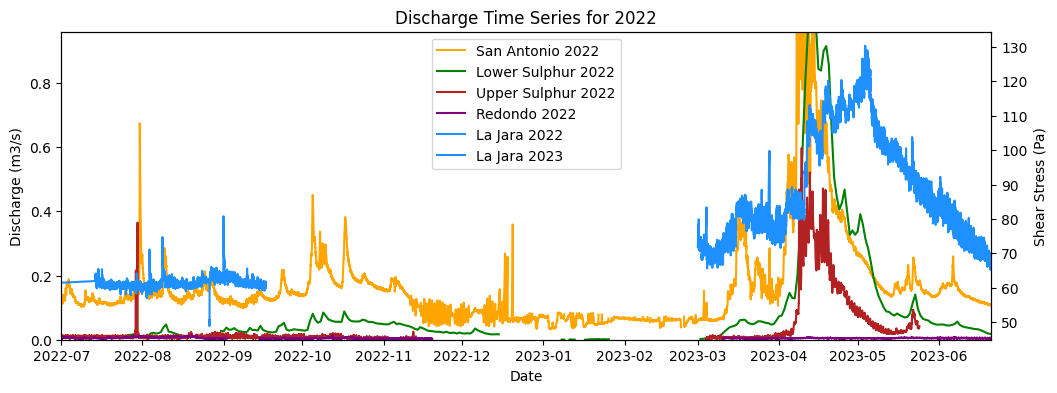

In [5]:
# plot discharge time series for all 4 sites
# 2022
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(san_antonio.index, san_antonio['san_antonio (m3/s)'], label='San Antonio 2022', color='orange')
ax.plot(lower_sulphur.index, lower_sulphur['lower_sulphur (m3/s)'], label='Lower Sulphur 2022', color='green')
ax.plot(upper_sulphur.index, upper_sulphur['upper_sulphur (m3/s)'], label='Upper Sulphur 2022', color='firebrick')
ax.plot(redondo.index, redondo['redondo (m3/s)'], label='Redondo 2022', color='purple')
ax.set_ylabel('Discharge (m3/s)')
ax.grid(False)

ax2 = ax.twinx()
ax2.plot(lajara_2022.index, lajara_2022['la_jara'], label='La Jara 2022', color='dodgerblue')
ax2.plot(lajara_2023.index, lajara_2023['la_jara'], label='La Jara 2023', color= 'dodgerblue')
ax2.set_ylabel('Shear Stress (Pa)')
ax2.grid(False)

# combine legends from both axes
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='best')

ax.set_ylim(0, 0.96)
ax.set_title('Discharge Time Series for 2022')
ax.set_xlabel('Date')
ax.set_xlim(pd.Timestamp('2022-07-01'), pd.Timestamp('2023-06-21'))
plt.show()

In [6]:
print(san_antonio['san_antonio (m3/s)'].loc['2022-09-01':'2023-02-05'].max())
print(san_antonio['san_antonio (m3/s)'].loc['2022-09-01':'2023-02-05'].idxmax())

0.451093730950464
2022-10-04 23:00:00


## 2021

In [7]:
# merge all onto la_jara 2021 index (inner join to only keep dates available in la_jara_2021)
lajara_2021 = lajara_2021[(lajara_2021.index >= '2021-08-01')]
merged_2021 = lajara_2021.copy()
merged_2021 = merged_2021.join([
    redondo[['redondo (m3/s)']],
    san_antonio[['san_antonio (m3/s)']],
    lower_sulphur[['lower_sulphur (m3/s)']],
    upper_sulphur[['upper_sulphur (m3/s)']],
    jemez[['jemez (ft)']]
], how='left')

print(merged_2021.head())
print(f"Shape: {merged_2021.shape}")

                       la_jara  redondo (m3/s)  san_antonio (m3/s)  \
2021-08-01 00:00:00  64.500604        0.003470            0.114706   
2021-08-01 00:15:00  64.500604        0.003794            0.115739   
2021-08-01 00:30:00  64.500604        0.003763            0.117097   
2021-08-01 00:45:00  64.500604        0.003467            0.120654   
2021-08-01 01:00:00  64.500604        0.003467            0.117900   

                     lower_sulphur (m3/s)  upper_sulphur (m3/s)  jemez (ft)  
2021-08-01 00:00:00              0.014357              0.010209         NaN  
2021-08-01 00:15:00                   NaN              0.010539         NaN  
2021-08-01 00:30:00                   NaN              0.010638         NaN  
2021-08-01 00:45:00                   NaN              0.010510         NaN  
2021-08-01 01:00:00                   NaN              0.010311         NaN  
Shape: (4609, 6)


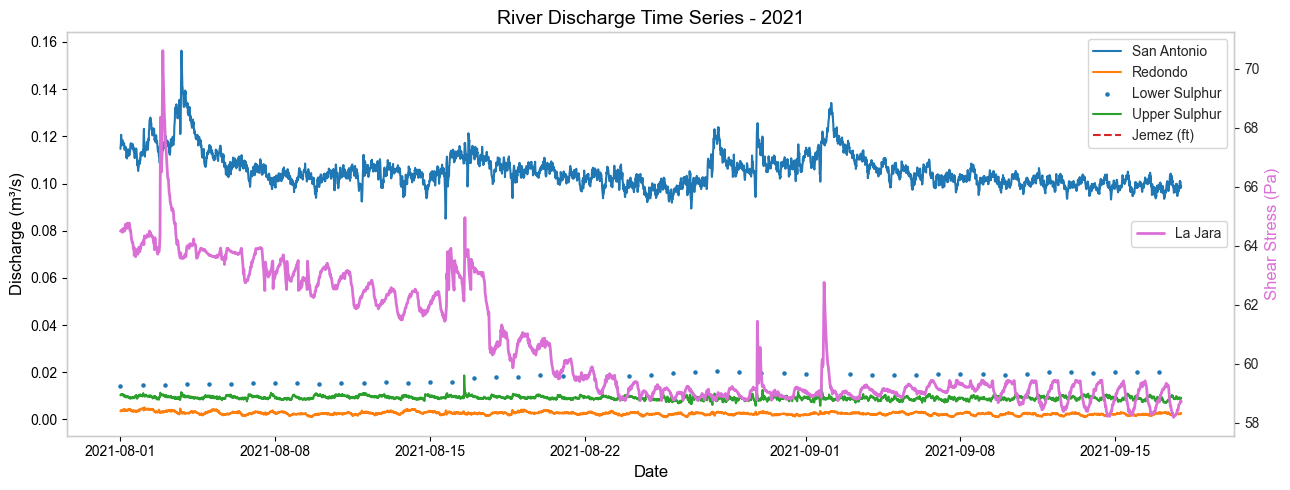

In [8]:
fig, ax = plt.subplots(figsize=(13, 5))
sns.set_style("whitegrid")

ax.plot(merged_2021.index, merged_2021['san_antonio (m3/s)'], label='San Antonio', linewidth=1.5)
ax.plot(merged_2021.index, merged_2021['redondo (m3/s)'], label='Redondo', linewidth=1.5)
ax.scatter(merged_2021.index, merged_2021['lower_sulphur (m3/s)'], label='Lower Sulphur', s=5)
ax.plot(merged_2021.index, merged_2021['upper_sulphur (m3/s)'], label='Upper Sulphur', linewidth=1.5)
ax.plot(merged_2021.index, merged_2021['jemez (ft)'], label='Jemez (ft)', linewidth=1.5, linestyle='--')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Discharge (m³/s)', fontsize=12)
ax.set_title('River Discharge Time Series - 2021', fontsize=14)
ax.legend(loc='best')
ax.grid(False)

ax2 = ax.twinx()
ax2.plot(merged_2021.index, merged_2021['la_jara'], label='La Jara', linewidth=2, color='orchid')
ax2.set_ylabel('Shear Stress (Pa)', fontsize=12, color='orchid')
ax2.legend(loc='center right')
ax2.grid(False)

plt.xticks(rotation=45)
plt.tight_layout()
#plt.ylim(0, 0.1)
plt.show()

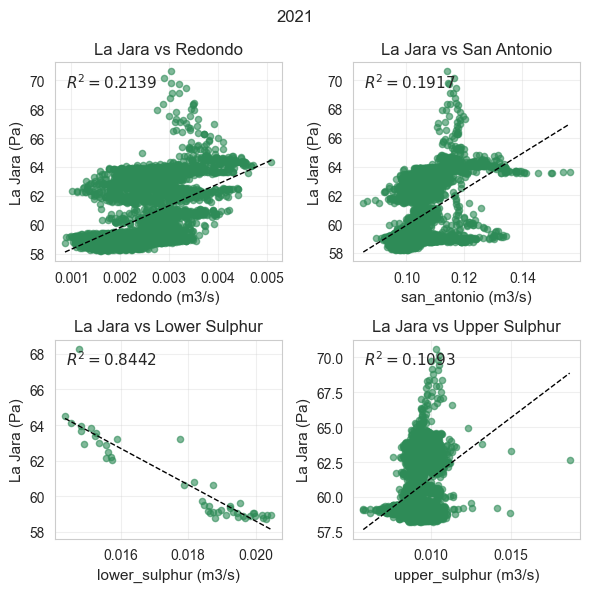

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
fig.suptitle('2021', fontsize=12)
sns.set_style("whitegrid")

# define the pairs: (x_column, subplot_position, title)
pairs = [
    ('redondo (m3/s)', axes[0, 0], 'La Jara vs Redondo'),
    ('san_antonio (m3/s)', axes[0, 1], 'La Jara vs San Antonio'),
    ('lower_sulphur (m3/s)', axes[1, 0], 'La Jara vs Lower Sulphur'),
    ('upper_sulphur (m3/s)', axes[1, 1], 'La Jara vs Upper Sulphur')
]

for x_col, ax, title in pairs:
    # remove NaN values for the regression
    valid_data = merged_2021[[x_col, 'la_jara']].dropna()
    # scatter plot
    ax.scatter(valid_data[x_col], valid_data['la_jara'], alpha=0.6, s=20, color='seagreen')
    # Linear regression
    slope, intercept, r_value, p_value, std_err = linregress(valid_data[x_col], valid_data['la_jara'])
    r2 = r_value**2
    
    # plot regression line
    x_line = np.array([valid_data[x_col].min(), valid_data[x_col].max()])
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1)
    
    # Labels and title with R² value
    ax.set_xlabel(x_col, fontsize=11)
    ax.set_ylabel('La Jara (Pa)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.text(0.05, 0.95, f'$R^2 = {r2:.4f}$', transform=ax.transAxes, fontsize=11, verticalalignment='top')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2022

In [10]:
lajara_2022 = lajara_2022[(lajara_2022.index >= '2022-08-01')] #& (lajara_2022.index < '2022-08-29')] # only keeping summer 
merged_2022 = lajara_2022.copy()
merged_2022 = merged_2022.join([
    redondo[['redondo (m3/s)']],
    san_antonio[['san_antonio (m3/s)']],
    lower_sulphur[['lower_sulphur (m3/s)']],
    upper_sulphur[['upper_sulphur (m3/s)']],
    jemez[['jemez (ft)']]
], how='left')

print(merged_2022.head())
print(f"Shape: {merged_2022.shape}")

                       la_jara  redondo (m3/s)  san_antonio (m3/s)  \
2022-08-01 00:00:00  60.721384        0.008724            0.250340   
2022-08-01 00:15:00  60.852264        0.008664            0.249357   
2022-08-01 00:30:00  60.090494        0.008425            0.245818   
2022-08-01 00:45:00  60.677277        0.009048            0.245451   
2022-08-01 01:00:00  60.456443        0.008545            0.241461   

                     lower_sulphur (m3/s)  upper_sulphur (m3/s)  jemez (ft)  
2022-08-01 00:00:00              0.007619              0.005346         NaN  
2022-08-01 00:15:00                   NaN              0.005164         NaN  
2022-08-01 00:30:00                   NaN              0.004985         NaN  
2022-08-01 00:45:00                   NaN              0.005385         NaN  
2022-08-01 01:00:00                   NaN              0.005630         NaN  
Shape: (4515, 6)


In [11]:
print(merged_2022['san_antonio (m3/s)'].loc['2022-09-01':'2023-02-05'].max())
print(merged_2022['san_antonio (m3/s)'].loc['2022-09-01':'2023-02-05'].idxmax())

0.1503343887828096
2022-09-15 00:00:00


In [12]:
print(merged_2022.index[:5])
print(san_antonio.index[:5])

DatetimeIndex(['2022-08-01 00:00:00', '2022-08-01 00:15:00',
               '2022-08-01 00:30:00', '2022-08-01 00:45:00',
               '2022-08-01 01:00:00'],
              dtype='datetime64[ns]', freq=None)
DatetimeIndex(['2008-04-16 13:58:00', '2008-04-16 14:08:00',
               '2008-04-16 14:18:00', '2008-04-16 14:28:00',
               '2008-04-16 14:38:00'],
              dtype='datetime64[ns]', name='Timestamp (UTC-07:00)', freq=None)


In [13]:
print(pd.Timestamp("2022-10-04 23:00:00") in merged_2022.index)

False


In [14]:
san_antonio['san_antonio (m3/s)'].count()
merged_2022['san_antonio (m3/s)'].count()

np.int64(4514)

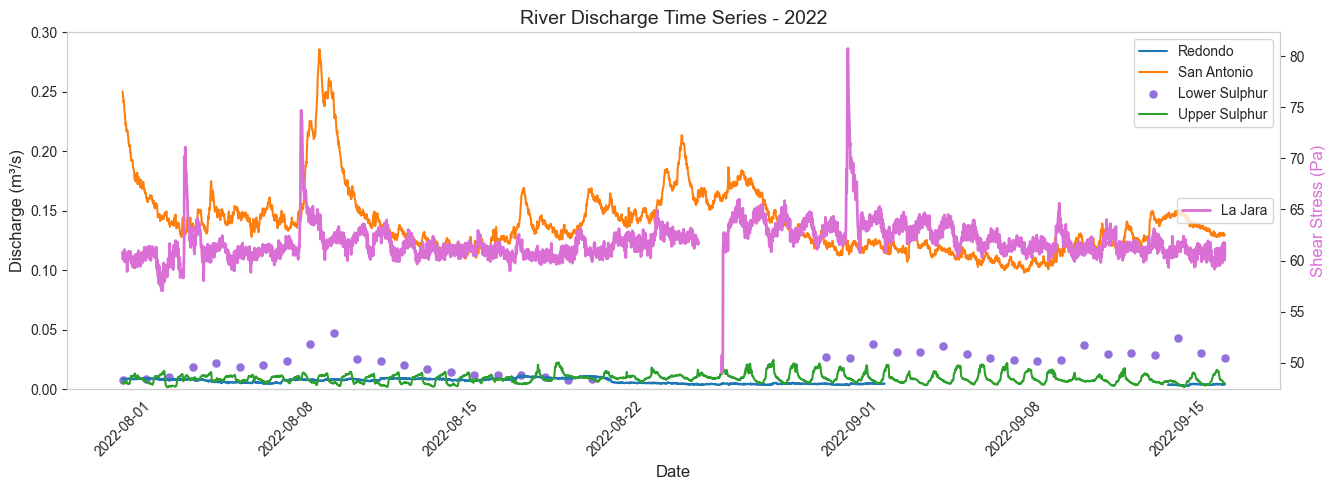

In [15]:
fig, ax = plt.subplots(figsize=(13, 5))
sns.set_style("whitegrid")

ax.plot(merged_2022.index, merged_2022['redondo (m3/s)'], label='Redondo', linewidth=1.5)
ax.plot(merged_2022.index, merged_2022['san_antonio (m3/s)'], label='San Antonio', linewidth=1.5)
ax.scatter(merged_2022.index, merged_2022['lower_sulphur (m3/s)'], label='Lower Sulphur', linewidth=0.1, color='mediumpurple')
ax.plot(merged_2022.index, merged_2022['upper_sulphur (m3/s)'], label='Upper Sulphur', linewidth=1.5)
ax.grid(False)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Discharge (m³/s)', fontsize=12)
ax.set_title('River Discharge Time Series - 2022', fontsize=14)
ax.legend(loc='best')
plt.xticks(rotation=45)
plt.tight_layout()
ax.set_ylim(0, 0.3)


ax2 = ax.twinx()
ax2.plot(merged_2022.index, merged_2022['la_jara'], label='La Jara', linewidth=2, color='orchid')
ax2.set_ylabel('Shear Stress (Pa)', fontsize=12, color='orchid')
ax2.legend(loc='center right')
ax2.grid(False)

#plt.xlim(pd.to_datetime('2022-08-01'), merged_2022.index.max())

plt.show()

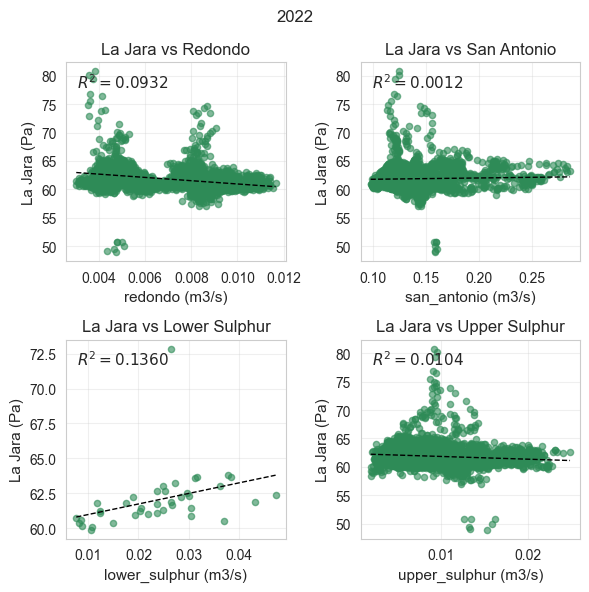

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
fig.suptitle('2022', fontsize=12)
sns.set_style("whitegrid")

# define the pairs: (x_column, subplot_position, title)
pairs = [
    ('redondo (m3/s)', axes[0, 0], 'La Jara vs Redondo'),
    ('san_antonio (m3/s)', axes[0, 1], 'La Jara vs San Antonio'),
    ('lower_sulphur (m3/s)', axes[1, 0], 'La Jara vs Lower Sulphur'),
    ('upper_sulphur (m3/s)', axes[1, 1], 'La Jara vs Upper Sulphur')
]

for x_col, ax, title in pairs:
    # remove NaN values for the regression
    valid_data = merged_2022[[x_col, 'la_jara']].dropna()
    # scatter plot
    ax.scatter(valid_data[x_col], valid_data['la_jara'], alpha=0.6, s=20, color='seagreen')
    # Linear regression
    slope, intercept, r_value, p_value, std_err = linregress(valid_data[x_col], valid_data['la_jara'])
    r2 = r_value**2
    
    # plot regression line
    x_line = np.array([valid_data[x_col].min(), valid_data[x_col].max()])
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1)
    
    # Labels and title with R² value
    ax.set_xlabel(x_col, fontsize=11)
    ax.set_ylabel('La Jara (Pa)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.text(0.05, 0.95, f'$R^2 = {r2:.4f}$', transform=ax.transAxes, fontsize=11, verticalalignment='top')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2023

In [17]:
# merge all onto la_jara 2021 index (inner join to only keep dates available in la_jara_2021)
lajara_2023 = lajara_2023[(lajara_2023.index >= '2023-04-01')] #& (lajara_2023.index < '2023-12-01')] # only keep summer data
merged_2023 = lajara_2023.copy()
merged_2023 = merged_2023.join([
    redondo[['redondo (m3/s)']],
    san_antonio[['san_antonio (m3/s)']],
    lower_sulphur[['lower_sulphur (m3/s)']],
    upper_sulphur[['upper_sulphur (m3/s)']],
    jemez[['jemez (ft)']]
], how='left')

print(merged_2023.head())
print(f"Shape: {merged_2023.shape}")

                       la_jara  redondo (m3/s)  san_antonio (m3/s)  \
2023-04-01 00:00:00  79.798356        0.004080            0.183147   
2023-04-01 00:15:00  79.153686        0.004243                 NaN   
2023-04-01 00:30:00  79.503420        0.004584            0.181196   
2023-04-01 00:45:00  80.609246        0.004275                 NaN   
2023-04-01 01:00:00  79.466979        0.004283            0.173708   

                     lower_sulphur (m3/s)  upper_sulphur (m3/s)  jemez (ft)  
2023-04-01 00:00:00              0.073167              0.008996        4.25  
2023-04-01 00:15:00                   NaN                   NaN        4.25  
2023-04-01 00:30:00                   NaN              0.008445        4.25  
2023-04-01 00:45:00                   NaN                   NaN        4.25  
2023-04-01 01:00:00                   NaN              0.008564        4.25  
Shape: (16325, 6)


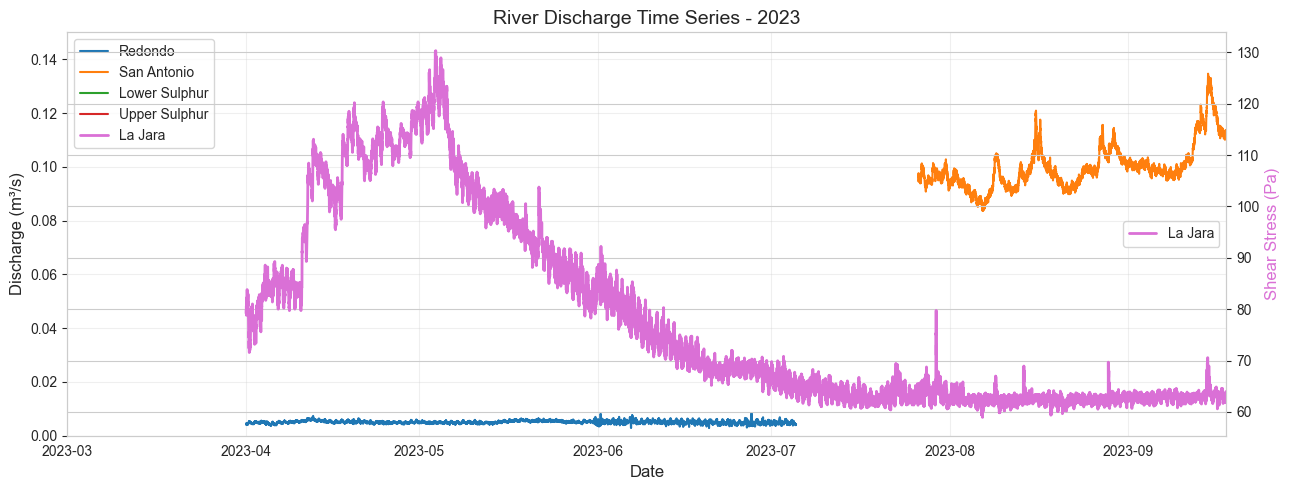

In [18]:
fig, ax = plt.subplots(figsize=(13, 5))
sns.set_style("whitegrid")


ax.plot(merged_2023.index, merged_2023['redondo (m3/s)'], label='Redondo', linewidth=1.5)
ax.plot(merged_2023.index, merged_2023['san_antonio (m3/s)'], label='San Antonio', linewidth=1.5)
ax.plot(merged_2023.index, merged_2023['lower_sulphur (m3/s)'], label='Lower Sulphur', linewidth=1.5)
ax.plot(merged_2023.index, merged_2023['upper_sulphur (m3/s)'], label='Upper Sulphur', linewidth=1.5)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Discharge (m³/s)', fontsize=12)
ax.set_title('River Discharge Time Series - 2023', fontsize=14)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 0.15)

# twin axis for Jemez gauge height
ax2 = ax.twinx()
ax2.plot(merged_2023.index, merged_2023['la_jara'], label='La Jara', linewidth=2, color='orchid')
ax2.set_ylabel('Shear Stress (Pa)', fontsize=12, color='orchid')
ax2.legend(loc='center right')

# combine legends from both axes
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.xlim(pd.to_datetime('2023-03-01'), merged_2023.index.max())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

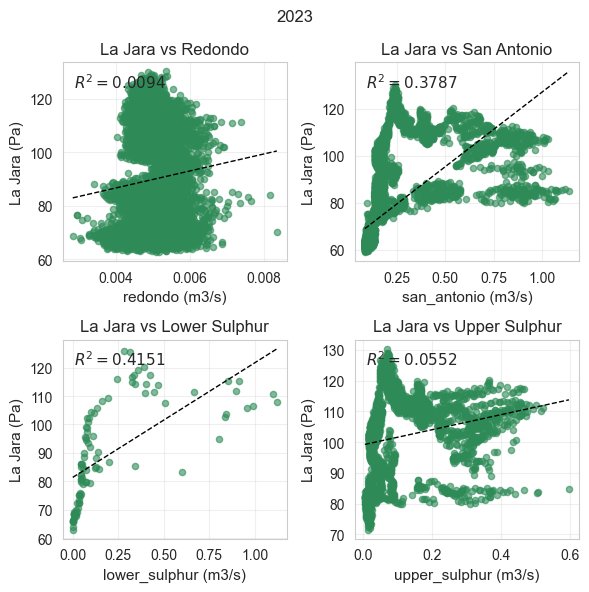

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
fig.suptitle('2023', fontsize=12)
sns.set_style("whitegrid")

# define the pairs: (x_column, subplot_position, title)
pairs = [
    ('redondo (m3/s)', axes[0, 0], 'La Jara vs Redondo'),
    ('san_antonio (m3/s)', axes[0, 1], 'La Jara vs San Antonio'),
    ('lower_sulphur (m3/s)', axes[1, 0], 'La Jara vs Lower Sulphur'),
    ('upper_sulphur (m3/s)', axes[1, 1], 'La Jara vs Upper Sulphur')
]

for x_col, ax, title in pairs:
    # remove NaN values for the regression
    valid_data = merged_2023[[x_col, 'la_jara']].dropna()
    # scatter plot
    ax.scatter(valid_data[x_col], valid_data['la_jara'], alpha=0.6, s=20, color='seagreen')
    # Linear regression
    slope, intercept, r_value, p_value, std_err = linregress(valid_data[x_col], valid_data['la_jara'])
    r2 = r_value**2
    
    # plot regression line
    x_line = np.array([valid_data[x_col].min(), valid_data[x_col].max()])
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1)
    
    # Labels and title with R² value
    ax.set_xlabel(x_col, fontsize=11)
    ax.set_ylabel('La Jara (Pa)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.text(0.05, 0.95, f'$R^2 = {r2:.4f}$', transform=ax.transAxes, fontsize=11, verticalalignment='top')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

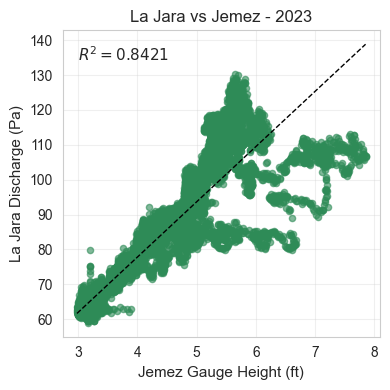

In [20]:
fig, ax = plt.subplots(figsize=(4, 4))
sns.set_style("whitegrid")

# remove NaN values for the regression
valid_data = merged_2023[['jemez (ft)', 'la_jara']].dropna()

# scatter plot
ax.scatter(valid_data['jemez (ft)'], valid_data['la_jara'], alpha=0.6, s=20, color='seagreen')

# Linear regression
slope, intercept, r_value, p_value, std_err = linregress(valid_data['jemez (ft)'], valid_data['la_jara'])
r2 = r_value**2

# plot regression line
x_line = np.array([valid_data['jemez (ft)'].min(), valid_data['jemez (ft)'].max()])
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1)

# Labels and title with R² value
ax.set_xlabel('Jemez Gauge Height (ft)', fontsize=11)
ax.set_ylabel('La Jara Discharge (Pa)', fontsize=11)
ax.set_title('La Jara vs Jemez - 2023', fontsize=12)
ax.text(0.05, 0.95, f'$R^2 = {r2:.4f}$', transform=ax.transAxes, fontsize=11, verticalalignment='top')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## All years

In [21]:
# combine all years
merged_all = pd.concat([merged_2021, merged_2022, merged_2023])

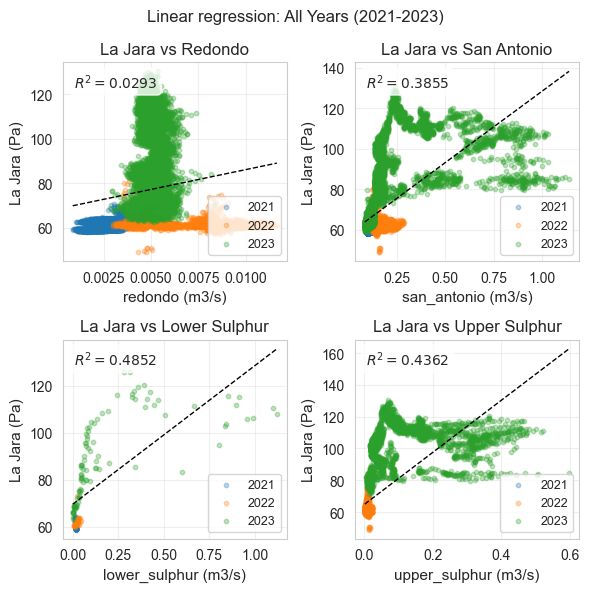

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
sns.set_style("whitegrid")
fig.suptitle('Linear regression: All Years (2021-2023)', fontsize=12)

pairs = [
    ('redondo (m3/s)', axes[0, 0], 'La Jara vs Redondo'),
    ('san_antonio (m3/s)', axes[0, 1], 'La Jara vs San Antonio'),
    ('lower_sulphur (m3/s)', axes[1, 0], 'La Jara vs Lower Sulphur'),
    ('upper_sulphur (m3/s)', axes[1, 1], 'La Jara vs Upper Sulphur')
]

colors = {'2021': '#1f77b4', '2022': '#ff7f0e', '2023': '#2ca02c'}  # blue, orange, green

for x_col, ax, title in pairs:
    valid_data = merged_all[[x_col, 'la_jara']].dropna()
    
    # scatter plot by year with different colors
    for year, color in colors.items():
        year_data = valid_data[valid_data.index.year == int(year)]
        ax.scatter(year_data[x_col], year_data['la_jara'], alpha=0.3, s=10, color=color, label=year)
    
    # linear regression
    slope, intercept, r_value, p_value, std_err = linregress(valid_data[x_col], valid_data['la_jara'])
    r2 = r_value**2
    
    # plot regression line
    x_line = np.array([valid_data[x_col].min(), valid_data[x_col].max()])
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1)
    
    # Labels and title with R² value
    ax.set_xlabel(x_col, fontsize=11)
    ax.set_ylabel('La Jara (Pa)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.text(0.05, 0.95, f'$R^2 = {r2:.4f}$', 
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [23]:
pairs = [
    ('redondo (m3/s)', 'La Jara vs Redondo'),
    ('san_antonio (m3/s)', 'La Jara vs San Antonio'),
    ('lower_sulphur (m3/s)', 'La Jara vs Lower Sulphur'),
    ('upper_sulphur (m3/s)', 'La Jara vs Upper Sulphur')
]

print("Linear Regression Metrics: All Years (2021-2023)\n")
print("-" * 80)

for x_col, title in pairs:
    valid_data = merged_all[[x_col, 'la_jara']].dropna()

    if len(valid_data) < 2:
        print(f"{title}: not enough data\n")
        continue

    x = valid_data[x_col].values
    y = valid_data['la_jara'].values

    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    r2 = r_value**2

    print(f"{title}:")
    print(f"  Equation: y = {slope:.6f} * x + {intercept:.6f}")
    print(f"  R² = {r2:.4f}")
    print(f"  p-value = {p_value:.4e}")
    print(f"  Std Err (slope) = {std_err:.6f}")
    print(f"  n = {len(valid_data)}")
    print()

print("-" * 80)

Linear Regression Metrics: All Years (2021-2023)

--------------------------------------------------------------------------------
La Jara vs Redondo:
  Equation: y = 1780.836517 * x + 68.259888
  R² = 0.0293
  p-value = 5.7486e-112
  Std Err (slope) = 78.610685
  n = 17026

La Jara vs San Antonio:
  Equation: y = 70.270108 * x + 57.972921
  R² = 0.3855
  p-value = 0.0000e+00
  Std Err (slope) = 0.631421
  n = 19744

La Jara vs Lower Sulphur:
  Equation: y = 58.983941 * x + 69.463959
  R² = 0.4852
  p-value = 2.4980e-28
  Std Err (slope) = 4.479408
  n = 186

La Jara vs Upper Sulphur:
  Equation: y = 163.861977 * x + 64.711237
  R² = 0.4362
  p-value = 0.0000e+00
  Std Err (slope) = 1.729877
  n = 11600

--------------------------------------------------------------------------------


### Different curve types

In [24]:
from scipy.optimize import curve_fit

# define exponential function
def exponential(x, a, b):
    return a * np.exp(b * x)

def logarithmic(x, a, b):
    return a * np.log(x) + b

def power_law(x, a, b):
    return a * x**b

Exponential

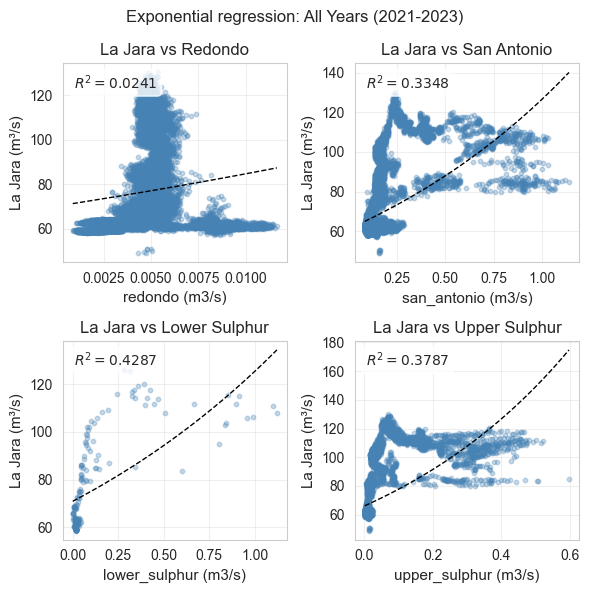

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
sns.set_style("whitegrid")
fig.suptitle('Exponential regression: All Years (2021-2023)', fontsize=12)

pairs = [
    ('redondo (m3/s)', axes[0, 0], 'La Jara vs Redondo'),
    ('san_antonio (m3/s)', axes[0, 1], 'La Jara vs San Antonio'),
    ('lower_sulphur (m3/s)', axes[1, 0], 'La Jara vs Lower Sulphur'),
    ('upper_sulphur (m3/s)', axes[1, 1], 'La Jara vs Upper Sulphur')
]

for x_col, ax, title in pairs:
    valid_data = merged_all[[x_col, 'la_jara']].dropna()
    
    x = valid_data[x_col].values
    y = valid_data['la_jara'].values
    
    # scatter plot
    ax.scatter(x, y, alpha=0.3, s=10, color='steelblue')
    # exponential regression
    try:
        popt, _ = curve_fit(exponential, x, y, p0=[0.01, 0.1], maxfev=5000)
        
        # Calculate R²
        y_pred = exponential(x, *popt)
        residuals = y - y_pred
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        r2 = 1 - (ss_res / ss_tot)
        
        # plot regression line
        x_line = np.linspace(x.min(), x.max(), 100)
        y_line = exponential(x_line, *popt)
        ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1)
        
        # Labels and title with R² value
        ax.set_xlabel(x_col, fontsize=11)
        ax.set_ylabel('La Jara (m³/s)', fontsize=11)
        ax.set_title(title, fontsize=12)
        ax.text(0.05, 0.95, f'$R^2 = {r2:.4f}$', 
                transform=ax.transAxes, fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    except:
        ax.set_xlabel(x_col, fontsize=11)
        ax.set_ylabel('La Jara (Pa)', fontsize=11)
        ax.set_title(title + ' (fit failed)', fontsize=12)
    
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
# print the equations for each subplot
equations = []
for x_col, ax, title in pairs:
    valid_data = merged_all[[x_col, 'la_jara']].dropna()
    x = valid_data[x_col].values
    y = valid_data['la_jara'].values
    try:
        popt, _ = curve_fit(exponential, x, y, p0=[0.01, 0.1], maxfev=5000)
        equation = f"y = {popt[0]:.4f} * e^({popt[1]:.4f} * x)"
        equations.append(equation)
        y_pred = exponential(x, *popt)
        residuals = y - y_pred
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        r2 = 1 - (ss_res / ss_tot)
        print(f"{title}: {equation}, R² = {r2:.4f}")
    except:
        equations.append("Failed to fit")
        print(f"{title}: Failed to fit")

La Jara vs Redondo: y = 70.1066 * e^(18.8641 * x), R² = 0.0241
La Jara vs San Antonio: y = 61.1703 * e^(0.7268 * x), R² = 0.3348
La Jara vs Lower Sulphur: y = 70.9263 * e^(0.5688 * x), R² = 0.4287
La Jara vs Upper Sulphur: y = 66.0538 * e^(1.6288 * x), R² = 0.3787


Logarithmic

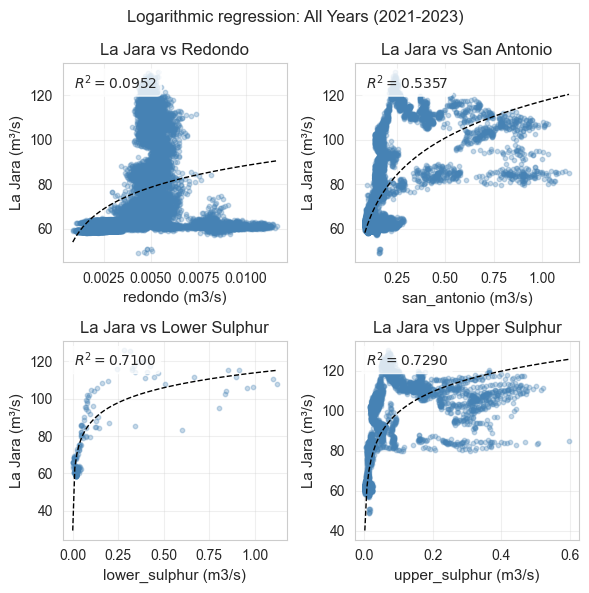

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
sns.set_style("whitegrid")
fig.suptitle('Logarithmic regression: All Years (2021-2023)', fontsize=12)

pairs = [
    ('redondo (m3/s)', axes[0, 0], 'La Jara vs Redondo'),
    ('san_antonio (m3/s)', axes[0, 1], 'La Jara vs San Antonio'),
    ('lower_sulphur (m3/s)', axes[1, 0], 'La Jara vs Lower Sulphur'),
    ('upper_sulphur (m3/s)', axes[1, 1], 'La Jara vs Upper Sulphur')
]

for x_col, ax, title in pairs:
    valid_data = merged_all[[x_col, 'la_jara']].dropna()
    
    x = valid_data[x_col].values
    y = valid_data['la_jara'].values
    
    # scatter plot
    ax.scatter(x, y, alpha=0.3, s=10, color='steelblue')
    # logarithmic regression
    try:
        popt, _ = curve_fit(logarithmic, x, y, p0=[0.01, 0.1], maxfev=5000)
        
        # Calculate R²
        y_pred = logarithmic(x, *popt)
        residuals = y - y_pred
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        r2 = 1 - (ss_res / ss_tot)
        
        # plot regression line
        x_line = np.linspace(x.min(), x.max(), 100)
        y_line = logarithmic(x_line, *popt)
        ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1)
        
        # Labels and title with R² value
        ax.set_xlabel(x_col, fontsize=11)
        ax.set_ylabel('La Jara (m³/s)', fontsize=11)
        ax.set_title(title, fontsize=12)
        ax.text(0.05, 0.95, f'$R^2 = {r2:.4f}$', 
                transform=ax.transAxes, fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    except:
        ax.set_xlabel(x_col, fontsize=11)
        ax.set_ylabel('La Jara (Pa)', fontsize=11)
        ax.set_title(title + ' (fit failed)', fontsize=12)
    
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [28]:
# print the equations for each subplot
equations = []
for x_col, ax, title in pairs:
    valid_data = merged_all[[x_col, 'la_jara']].dropna()
    x = valid_data[x_col].values
    y = valid_data['la_jara'].values
    try:
        popt, _ = curve_fit(logarithmic, x, y, p0=[0.01, 0.1], maxfev=5000)
        equation = f"y = {popt[0]:.4f} * ln({popt[1]:.4f} * x)"
        equations.append(equation)
        y_pred = logarithmic(x, *popt)
        residuals = y - y_pred
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        r2 = 1 - (ss_res / ss_tot)
        print(f"{title}: {equation}, R² = {r2:.4f}")
    except:
        equations.append("Failed to fit")
        print(f"{title}: Failed to fit")

La Jara vs Redondo: y = 14.0955 * ln(153.2856 * x), R² = 0.0952
La Jara vs San Antonio: y = 23.8211 * ln(117.3479 * x), R² = 0.5357
La Jara vs Lower Sulphur: y = 11.5136 * ln(113.7683 * x), R² = 0.7100
La Jara vs Upper Sulphur: y = 14.7663 * ln(133.2385 * x), R² = 0.7290


Power Law

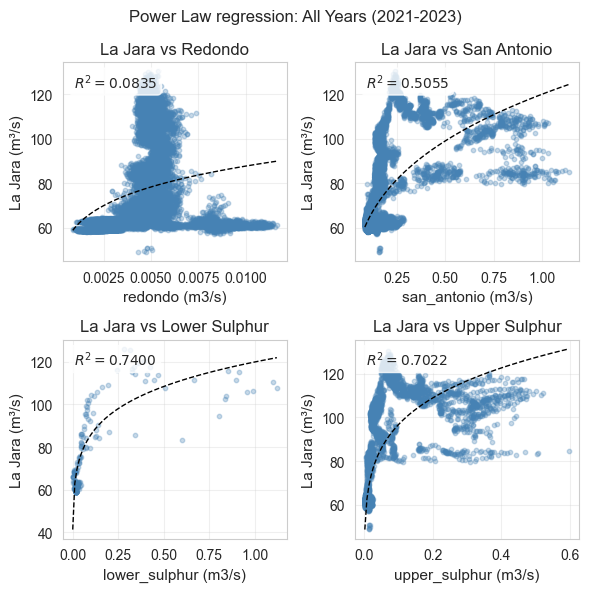

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
sns.set_style("whitegrid")
fig.suptitle('Power Law regression: All Years (2021-2023)', fontsize=12)

pairs = [
    ('redondo (m3/s)', axes[0, 0], 'La Jara vs Redondo'),
    ('san_antonio (m3/s)', axes[0, 1], 'La Jara vs San Antonio'),
    ('lower_sulphur (m3/s)', axes[1, 0], 'La Jara vs Lower Sulphur'),
    ('upper_sulphur (m3/s)', axes[1, 1], 'La Jara vs Upper Sulphur')
]

for x_col, ax, title in pairs:
    valid_data = merged_all[[x_col, 'la_jara']].dropna()
    
    x = valid_data[x_col].values
    y = valid_data['la_jara'].values
    
    # scatter plot
    ax.scatter(x, y, alpha=0.3, s=10, color='steelblue')
    # power law regression
    try:
        popt, _ = curve_fit(power_law, x, y, p0=[0.01, 0.1], maxfev=5000)
        
        # Calculate R²
        y_pred = power_law(x, *popt)
        residuals = y - y_pred
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        r2 = 1 - (ss_res / ss_tot)
        
        # plot regression line
        x_line = np.linspace(x.min(), x.max(), 100)
        y_line = power_law(x_line, *popt)
        ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1)
        
        # Labels and title with R² value
        ax.set_xlabel(x_col, fontsize=11)
        ax.set_ylabel('La Jara (m³/s)', fontsize=11)
        ax.set_title(title, fontsize=12)
        ax.text(0.05, 0.95, f'$R^2 = {r2:.4f}$', 
                transform=ax.transAxes, fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    except:
        ax.set_xlabel(x_col, fontsize=11)
        ax.set_ylabel('La Jara (Pa)', fontsize=11)
        ax.set_title(title + ' (fit failed)', fontsize=12)
    
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
# print the equations for each subplot
equations = []
for x_col, ax, title in pairs:
    valid_data = merged_all[[x_col, 'la_jara']].dropna()
    x = valid_data[x_col].values
    y = valid_data['la_jara'].values
    try:
        popt, _ = curve_fit(power_law, x, y, p0=[0.01, 0.1], maxfev=5000)
        equation = f"y = {popt[0]:.4f} * x^{popt[1]:.4f}"
        equations.append(equation)
        y_pred = power_law(x, *popt)
        residuals = y - y_pred
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        r2 = 1 - (ss_res / ss_tot)
        print(f"{title}: {equation}, R² = {r2:.4f}")
    except:
        equations.append("Failed to fit")
        print(f"{title}: Failed to fit")

La Jara vs Redondo: y = 186.3124 * x^0.1637, R² = 0.0835
La Jara vs San Antonio: y = 120.0026 * x^0.2773, R² = 0.5055
La Jara vs Lower Sulphur: y = 119.8530 * x^0.1455, R² = 0.7400
La Jara vs Upper Sulphur: y = 143.5442 * x^0.1714, R² = 0.7022


## Only fitting lower range of data

Using merged

In [126]:
# finding the max value of the low-flow period in 2022
redondo_low_flow_2022 = merged_all['redondo (m3/s)'][(merged_all.index >= '2022-07-10') & (merged_all.index <= '2023-03-05')]
san_antonio_low_flow_2022 = merged_all['san_antonio (m3/s)'][(merged_all.index >= '2022-07-01') & (merged_all.index <= '2023-03-05')]
lower_sulphur_low_flow_2022 = merged_all['lower_sulphur (m3/s)'][(merged_all.index >= '2022-07-01') & (merged_all.index <= '2023-03-05')]
upper_sulphur_low_flow_2022 = merged_all['upper_sulphur (m3/s)'][(merged_all.index >= '2022-07-01') & (merged_all.index <= '2023-03-05')]

print(f"Max Redondo low flow 2022: {redondo_low_flow_2022.max():.4f} m³/s")
print(f"Max San Antonio low flow 2022: {san_antonio_low_flow_2022.max():.4f} m³/s")
print(f"Max Lower Sulphur low flow 2022: {lower_sulphur_low_flow_2022.max():.4f} m³/s")
print(f"Max Upper Sulphur low flow 2022: {upper_sulphur_low_flow_2022.max():.4f} m³/s")

Max Redondo low flow 2022: 0.0117 m³/s
Max San Antonio low flow 2022: 0.2859 m³/s
Max Lower Sulphur low flow 2022: 0.0473 m³/s
Max Upper Sulphur low flow 2022: 0.0249 m³/s


Using individual stream

In [127]:
redondo_low_flow_2022 = redondo["redondo (m3/s)"][(redondo.index >= '2022-07-10') & (redondo.index <= '2023-03-05')]
san_antonio_low_flow_2022 = san_antonio["san_antonio (m3/s)"][(san_antonio.index >= '2022-07-10') & (san_antonio.index <= '2023-03-05')]
lower_sulphur_low_flow_2022 = lower_sulphur["lower_sulphur (m3/s)"][(lower_sulphur.index >= '2022-07-10') & (lower_sulphur.index <= '2023-03-05')]
upper_sulphur_low_flow_2022 = upper_sulphur["upper_sulphur (m3/s)"][(upper_sulphur.index >= '2022-07-10') & (upper_sulphur.index <= '2023-03-05')]
jemez_low_flow_2022 = jemez["jemez (ft)"][(jemez.index >= '2022-07-10') & (jemez.index <= '2023-03-05')]

print(f"Max Redondo low flow 2022: {redondo_low_flow_2022.max():.4f} m³/s")
print(f"Max San Antonio low flow 2022: {san_antonio_low_flow_2022.max():.4f} m³/s")
print(f"Max Lower Sulphur low flow 2022: {lower_sulphur_low_flow_2022.max():.4f} m³/s")
print(f"Max Upper Sulphur low flow 2022: {upper_sulphur_low_flow_2022.max():.4f} m³/s")
print(f"Max Jemez low flow 2022: {jemez_low_flow_2022.max():.4f} ft")

Max Redondo low flow 2022: 0.0152 m³/s
Max San Antonio low flow 2022: 0.6748 m³/s
Max Lower Sulphur low flow 2022: 0.0880 m³/s
Max Upper Sulphur low flow 2022: 0.3653 m³/s
Max Jemez low flow 2022: 3.7200 ft


In [128]:
#merged_all = merged_all[merged_all['la_jara'] <= 0.02] # only keep baseflow la jara

merged_redondo = merged_all[['redondo (m3/s)', 'la_jara']].dropna()
merged_san_antonio = merged_all[['san_antonio (m3/s)', 'la_jara']].dropna()
merged_lower_sulphur = merged_all[['lower_sulphur (m3/s)', 'la_jara']].dropna()
merged_upper_sulphur = merged_all[['upper_sulphur (m3/s)', 'la_jara']].dropna()
merged_jemez = merged_all[['jemez (ft)', 'la_jara']].dropna()

# only keep rows where discharge is less than or equal to the max low flow 
merged_redondo = merged_redondo[merged_redondo['redondo (m3/s)'] <= redondo_low_flow_2022.max()*0.8] 
merged_san_antonio = merged_san_antonio[merged_san_antonio['san_antonio (m3/s)'] <= san_antonio_low_flow_2022.max()*0.8] 
merged_lower_sulphur = merged_lower_sulphur[merged_lower_sulphur['lower_sulphur (m3/s)'] <= lower_sulphur_low_flow_2022.max()*0.8]
merged_upper_sulphur = merged_upper_sulphur[merged_upper_sulphur['upper_sulphur (m3/s)'] <= upper_sulphur_low_flow_2022.max()*0.8]
merged_jemez = merged_jemez[merged_jemez['jemez (ft)'] <= jemez_low_flow_2022.max()*0.8]

### Linear Low Flows

Redondo, San Antonio, Sulphur

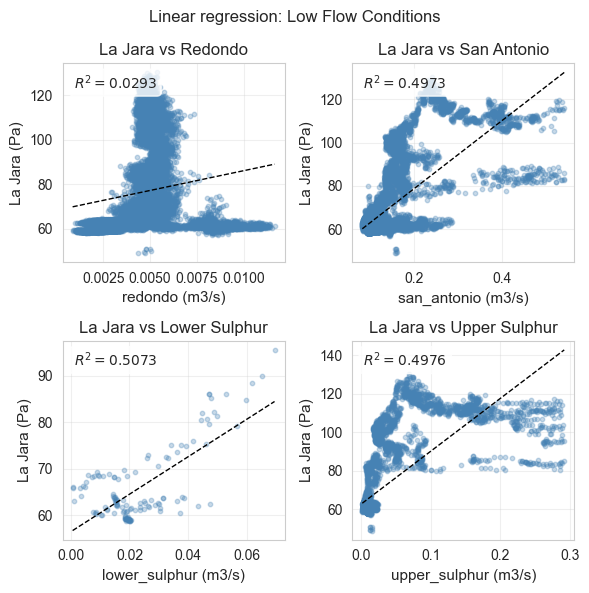

In [130]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
sns.set_style("whitegrid")
fig.suptitle('Linear regression: Low Flow Conditions', fontsize=12)

pairs = [
    (merged_redondo, 'redondo (m3/s)', axes[0, 0], 'La Jara vs Redondo'),
    (merged_san_antonio, 'san_antonio (m3/s)', axes[0, 1], 'La Jara vs San Antonio'),
    (merged_lower_sulphur, 'lower_sulphur (m3/s)', axes[1, 0], 'La Jara vs Lower Sulphur'),
    (merged_upper_sulphur, 'upper_sulphur (m3/s)', axes[1, 1], 'La Jara vs Upper Sulphur')
]

for df, x_col, ax, title in pairs:
    valid_data = df[[x_col, 'la_jara']].dropna()
    # scatter plot
    ax.scatter(valid_data[x_col], valid_data['la_jara'], alpha=0.3, s=10, color='steelblue')
    
    # linear regression
    slope, intercept, r_value, p_value, std_err = linregress(valid_data[x_col], valid_data['la_jara'])
    r2 = r_value**2
    
    # plot regression line
    x_line = np.array([valid_data[x_col].min(), valid_data[x_col].max()])
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1)
    
    # Labels and title with R² value
    ax.set_xlabel(x_col, fontsize=11)
    ax.set_ylabel('La Jara (Pa)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.text(0.05, 0.95, f'$R^2 = {r2:.4f}$', 
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [131]:
# print linear equations and metrics for low flow conditions
pairs = [
    (merged_redondo, 'redondo (m3/s)', 'La Jara vs Redondo'),
    (merged_san_antonio, 'san_antonio (m3/s)', 'La Jara vs San Antonio'),
    (merged_lower_sulphur, 'lower_sulphur (m3/s)', 'La Jara vs Lower Sulphur'),
    (merged_upper_sulphur, 'upper_sulphur (m3/s)', 'La Jara vs Upper Sulphur')
]
print("Linear Regression: Low Flow Conditions\n")
print("-" * 70)

for df, x_col, title in pairs:
    valid_data = df[[x_col, 'la_jara']].dropna()
    x = valid_data[x_col].values
    y = valid_data['la_jara'].values
    
    try:
        # perform linear regression
        slope, intercept, r_value, p_value, std_err = linregress(x, y)
        r2 = r_value**2
        
        equation = f"y = {slope:.6f} * x + {intercept:.6f}"
        print(f"{title}:")
        print(f"  Equation: {equation}")
        print(f"  R² = {r2:.4f}")
        print(f"  n = {len(valid_data)}")
        print()
    except:
        print(f"{title}: Failed to fit\n")

print("-" * 70)

Linear Regression: Low Flow Conditions

----------------------------------------------------------------------
La Jara vs Redondo:
  Equation: y = 1780.836517 * x + 68.259888
  R² = 0.0293
  n = 17026

La Jara vs San Antonio:
  Equation: y = 158.087865 * x + 47.025265
  R² = 0.4973
  n = 19122

La Jara vs Lower Sulphur:
  Equation: y = 404.806110 * x + 56.384596
  R² = 0.5073
  n = 132

La Jara vs Upper Sulphur:
  Equation: y = 274.764366 * x + 62.671192
  R² = 0.4976
  n = 11250

----------------------------------------------------------------------


### Exponential Low Flows

Redondo, San Antonio, Sulphur

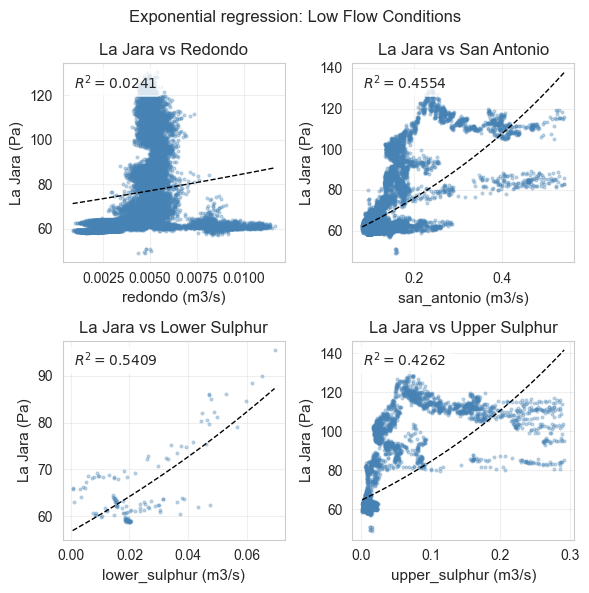

In [132]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
sns.set_style("whitegrid")
fig.suptitle('Exponential regression: Low Flow Conditions', fontsize=12)

pairs = [
    (merged_redondo, 'redondo (m3/s)', axes[0, 0], 'La Jara vs Redondo'),
    (merged_san_antonio, 'san_antonio (m3/s)', axes[0, 1], 'La Jara vs San Antonio'),
    (merged_lower_sulphur, 'lower_sulphur (m3/s)', axes[1, 0], 'La Jara vs Lower Sulphur'),
    (merged_upper_sulphur, 'upper_sulphur (m3/s)', axes[1, 1], 'La Jara vs Upper Sulphur')
]
for df, x_col, ax, title in pairs:
    valid_data = df[[x_col, 'la_jara']].dropna()
    x = valid_data[x_col].values
    y = valid_data['la_jara'].values
    
    # scatter plot by year with different colors
    for year, color in colors.items():
        year_data = valid_data[valid_data.index.year == int(year)]
        ax.scatter(year_data[x_col], year_data['la_jara'], alpha=0.3, s=4, color='steelblue', label=year)
    
    # exponential regression
    try:
        popt, _ = curve_fit(exponential, x, y, p0=[0.01, 0.1], maxfev=5000)
        
        # Calculate R²
        y_pred = exponential(x, *popt)
        residuals = y - y_pred
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        r2 = 1 - (ss_res / ss_tot)
    
        # plot regression line
        x_line = np.linspace(valid_data[x_col].min(), valid_data[x_col].max(), 100)
        y_line = exponential(x_line, *popt)
        ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1)
        # Labels and title with R² value
        ax.set_xlabel(x_col, fontsize=11)
        ax.set_ylabel('La Jara (Pa)', fontsize=11)
        ax.set_title(title, fontsize=12)
        ax.text(0.05, 0.95, f'$R^2 = {r2:.4f}$', 
                transform=ax.transAxes, fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        ax.grid(True, alpha=0.3)
    except:
        ax.set_xlabel(x_col, fontsize=11)
        ax.set_ylabel('La Jara (Pa)', fontsize=11)
        ax.set_title(title + ' (fit failed)', fontsize=12)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Equation Metrics

In [133]:
# print exponential equations and metrics for low flow conditions
pairs = [
    (merged_redondo, 'redondo (m3/s)', 'La Jara vs Redondo'),
    (merged_san_antonio, 'san_antonio (m3/s)', 'La Jara vs San Antonio'),
    (merged_lower_sulphur, 'lower_sulphur (m3/s)', 'La Jara vs Lower Sulphur'),
    (merged_upper_sulphur, 'upper_sulphur (m3/s)', 'La Jara vs Upper Sulphur')
]
print("Exponential Regression: Low Flow Conditions\n")
print("-" * 70)

for df, x_col, title in pairs:
    valid_data = df[[x_col, 'la_jara']].dropna()
    x = valid_data[x_col].values
    y = valid_data['la_jara'].values
    
    try:
        popt, _ = curve_fit(exponential, x, y, p0=[0.01, 0.1], maxfev=5000)
        
        # calculate R²
        y_pred = exponential(x, *popt)
        residuals = y - y_pred
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        r2 = 1 - (ss_res / ss_tot)
        
        equation = f"y = {popt[0]:.6f} * e^({popt[1]:.6f} * x)"
        print(f"{title}:")
        print(f"  Equation: {equation}")
        print(f"  R² = {r2:.4f}")
        print(f"  n = {len(valid_data)}")
        print()
    except:
        print(f"{title}: Failed to fit\n")

print("-" * 70)

Exponential Regression: Low Flow Conditions

----------------------------------------------------------------------
La Jara vs Redondo:
  Equation: y = 70.106627 * e^(18.864132 * x)
  R² = 0.0241
  n = 17026

La Jara vs San Antonio:
  Equation: y = 53.474604 * e^(1.753836 * x)
  R² = 0.4554
  n = 19122

La Jara vs Lower Sulphur:
  Equation: y = 56.685326 * e^(6.229386 * x)
  R² = 0.5409
  n = 132

La Jara vs Upper Sulphur:
  Equation: y = 64.471176 * e^(2.703944 * x)
  R² = 0.4262
  n = 11250

----------------------------------------------------------------------


### Separate by year

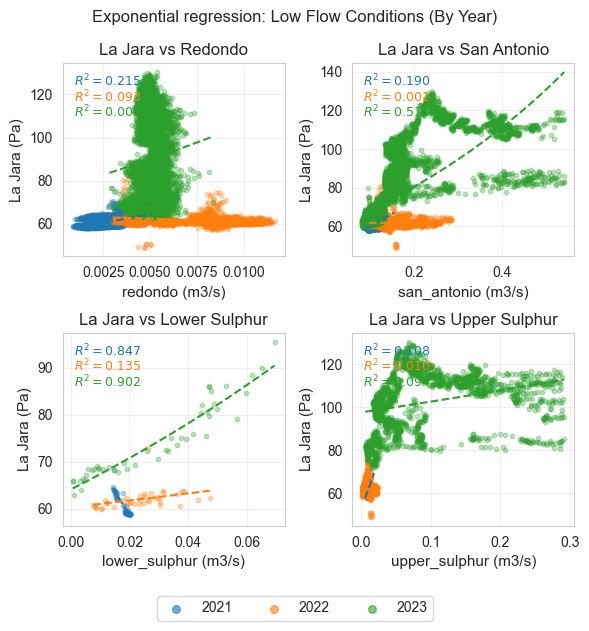

In [134]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
sns.set_style("whitegrid")
fig.suptitle('Exponential regression: Low Flow Conditions (By Year)', fontsize=12)

pairs = [
    (merged_redondo, 'redondo (m3/s)', axes[0, 0], 'La Jara vs Redondo'),
    (merged_san_antonio, 'san_antonio (m3/s)', axes[0, 1], 'La Jara vs San Antonio'),
    (merged_lower_sulphur, 'lower_sulphur (m3/s)', axes[1, 0], 'La Jara vs Lower Sulphur'),
    (merged_upper_sulphur, 'upper_sulphur (m3/s)', axes[1, 1], 'La Jara vs Upper Sulphur')
]

colors = {'2021': '#1f77b4', '2022': '#ff7f0e', '2023': '#2ca02c'}  # blue, orange, green

for df, x_col, ax, title in pairs:
    valid_data = df[[x_col, 'la_jara']].dropna()
    y_position = 0.95
    
    # fit exponential regression for each year separately
    for year, color in colors.items():
        year_data = valid_data[valid_data.index.year == int(year)]
        
        if len(year_data) > 0:
            x = year_data[x_col].values
            y = year_data['la_jara'].values
            
            # scatter plot
            ax.scatter(x, y, alpha=0.3, s=10, color=color, label=year)
            
            # exponential regression for this year
            try:
                popt, _ = curve_fit(exponential, x, y, p0=[0.01, 0.1], maxfev=5000)
                
                # Calculate R²
                y_pred = exponential(x, *popt)
                residuals = y - y_pred
                ss_res = np.sum(residuals**2)
                ss_tot = np.sum((y - np.mean(y))**2)
                r2 = 1 - (ss_res / ss_tot)
                
                # plot regression line
                x_line = np.linspace(x.min(), x.max(), 100)
                y_line = exponential(x_line, *popt)
                ax.plot(x_line, y_line, color=color, linestyle='--', linewidth=1.5)
                
                # Add R² text with matching color
                ax.text(0.05, y_position, f'$R^2 = {r2:.3f}$', 
                       transform=ax.transAxes, fontsize=9, verticalalignment='top',
                       color=color, weight='bold')
                y_position -= 0.08
                
            except:
                pass
    
    # Labels and title
    ax.set_xlabel(x_col, fontsize=11)
    ax.set_ylabel('La Jara (Pa)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.grid(True, alpha=0.3)

# Create a single legend at the bottom
handles = [plt.scatter([], [], color=colors[year], s=30, alpha=0.6) for year in ['2021', '2022', '2023']]
fig.legend(handles, ['2021', '2022', '2023'], loc='lower center', ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
plt.show()

Separating by year - Only Summer and Fall months

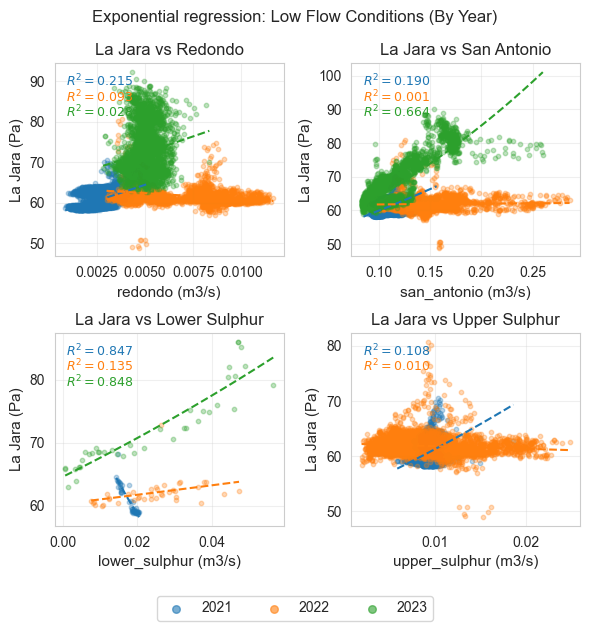

In [135]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
sns.set_style("whitegrid")
fig.suptitle('Exponential regression: Low Flow Conditions (By Year)', fontsize=12)

pairs = [
    (merged_redondo, 'redondo (m3/s)', axes[0, 0], 'La Jara vs Redondo'),
    (merged_san_antonio, 'san_antonio (m3/s)', axes[0, 1], 'La Jara vs San Antonio'),
    (merged_lower_sulphur, 'lower_sulphur (m3/s)', axes[1, 0], 'La Jara vs Lower Sulphur'),
    (merged_upper_sulphur, 'upper_sulphur (m3/s)', axes[1, 1], 'La Jara vs Upper Sulphur')
]

colors = {'2021': '#1f77b4', '2022': '#ff7f0e', '2023': '#2ca02c'}  # blue, orange, green

for df, x_col, ax, title in pairs:
    valid_data = df[[x_col, 'la_jara']].dropna()
    # keep only summer and fall months (June-November)
    valid_data = valid_data[(valid_data.index.month >= 6) & (valid_data.index.month <= 12)]
    y_position = 0.95
    
    # fit exponential regression for each year separately
    for year, color in colors.items():
        year_data = valid_data[valid_data.index.year == int(year)]
        
        if len(year_data) > 0:
            x = year_data[x_col].values
            y = year_data['la_jara'].values
            
            # scatter plot
            ax.scatter(x, y, alpha=0.3, s=10, color=color, label=year)
            
            # exponential regression for this year
            try:
                popt, _ = curve_fit(exponential, x, y, p0=[0.01, 0.1], maxfev=5000)
                
                # Calculate R²
                y_pred = exponential(x, *popt)
                residuals = y - y_pred
                ss_res = np.sum(residuals**2)
                ss_tot = np.sum((y - np.mean(y))**2)
                r2 = 1 - (ss_res / ss_tot)
                
                # plot regression line
                x_line = np.linspace(x.min(), x.max(), 100)
                y_line = exponential(x_line, *popt)
                ax.plot(x_line, y_line, color=color, linestyle='--', linewidth=1.5)
                
                # Add R² text with matching color
                ax.text(0.05, y_position, f'$R^2 = {r2:.3f}$', 
                       transform=ax.transAxes, fontsize=9, verticalalignment='top',
                       color=color, weight='bold')
                y_position -= 0.08
                
            except:
                pass
    
    # Labels and title
    ax.set_xlabel(x_col, fontsize=11)
    ax.set_ylabel('La Jara (Pa)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.grid(True, alpha=0.3)

# Create a single legend at the bottom
handles = [plt.scatter([], [], color=colors[year], s=30, alpha=0.6) for year in ['2021', '2022', '2023']]
fig.legend(handles, ['2021', '2022', '2023'], loc='lower center', ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
plt.show()

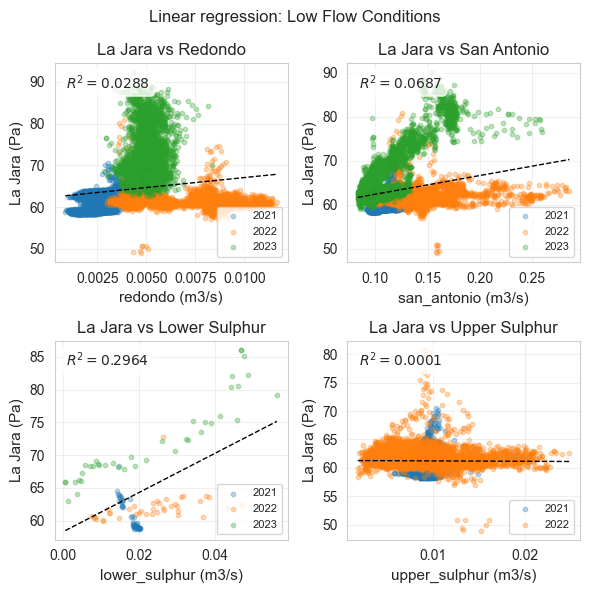

In [142]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
sns.set_style("whitegrid")
fig.suptitle('Linear regression: Low Flow Conditions', fontsize=12)

pairs = [
    (merged_redondo, 'redondo (m3/s)', axes[0, 0], 'La Jara vs Redondo'),
    (merged_san_antonio, 'san_antonio (m3/s)', axes[0, 1], 'La Jara vs San Antonio'),
    (merged_lower_sulphur, 'lower_sulphur (m3/s)', axes[1, 0], 'La Jara vs Lower Sulphur'),
    (merged_upper_sulphur, 'upper_sulphur (m3/s)', axes[1, 1], 'La Jara vs Upper Sulphur')
]

colors = {'2021': '#1f77b4', '2022': '#ff7f0e', '2023': '#2ca02c'}

for df, x_col, ax, title in pairs:
    valid_data = df[[x_col, 'la_jara']].dropna()
        # keep only summer and fall months (June-November)
    valid_data = valid_data[(valid_data.index.month >= 6) & (valid_data.index.month <= 12)]

    # scatter plot by year
    for year, color in colors.items():
        year_data = valid_data[valid_data.index.year == int(year)]
        if len(year_data) > 0:
            ax.scatter(year_data[x_col], year_data['la_jara'], alpha=0.3, s=10, color=color, label=year)

    # linear regression on all filtered data
    slope, intercept, r_value, p_value, std_err = linregress(valid_data[x_col], valid_data['la_jara'])
    r2 = r_value**2

    # plot regression line
    x_line = np.array([valid_data[x_col].min(), valid_data[x_col].max()])
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1)

    # Labels and title with R² value
    ax.set_xlabel(x_col, fontsize=11)
    ax.set_ylabel('La Jara (Pa)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.text(0.05, 0.95, f'$R^2 = {r2:.4f}$', 
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.grid(True, alpha=0.3)
    ax.legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

In [143]:
pairs = [
    ('redondo (m3/s)', 'La Jara vs Redondo'),
    ('san_antonio (m3/s)', 'La Jara vs San Antonio'),
    ('lower_sulphur (m3/s)', 'La Jara vs Lower Sulphur'),
    ('upper_sulphur (m3/s)', 'La Jara vs Upper Sulphur')
]

print("Linear Regression Metrics: Low Flows (2021-2022)\n")
print("-" * 80)

for x_col, title in pairs:
    valid_data = merged_all[[x_col, 'la_jara']].dropna()
    valid_data = valid_data[(valid_data.index.month >= 6) & (valid_data.index.month <= 12)]


    if len(valid_data) < 2:
        print(f"{title}: not enough data\n")
        continue

    x = valid_data[x_col].values
    y = valid_data['la_jara'].values

    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    r2 = r_value**2

    print(f"{title}:")
    print(f"  Equation: y = {slope:.6f} * x + {intercept:.6f}")
    print(f"  R² = {r2:.4f}")
    print(f"  p-value = {p_value:.4e}")
    print(f"  Std Err (slope) = {std_err:.6f}")
    print(f"  n = {len(valid_data)}")
    print()

print("-" * 80)

Linear Regression Metrics: Low Flows (2021-2022)

--------------------------------------------------------------------------------
La Jara vs Redondo:
  Equation: y = 477.939754 * x + 62.275295
  R² = 0.0288
  p-value = 5.7303e-73
  Std Err (slope) = 26.259129
  n = 11170

La Jara vs San Antonio:
  Equation: y = 42.596500 * x + 58.110195
  R² = 0.0687
  p-value = 4.6401e-262
  Std Err (slope) = 1.209881
  n = 16815

La Jara vs Lower Sulphur:
  Equation: y = 299.110312 * x + 58.286389
  R² = 0.2964
  p-value = 5.3023e-11
  Std Err (slope) = 41.557284
  n = 125

La Jara vs Upper Sulphur:
  Equation: y = -6.947556 * x + 61.294181
  R² = 0.0001
  p-value = 3.7326e-01
  Std Err (slope) = 7.802432
  n = 9028

--------------------------------------------------------------------------------


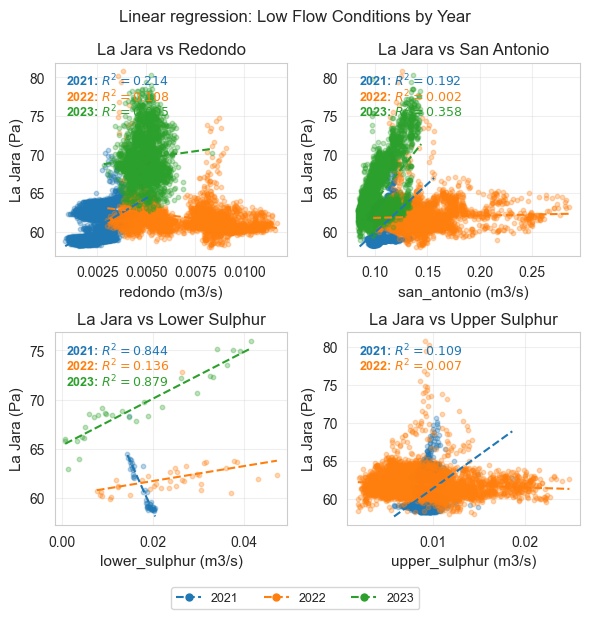

In [149]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
sns.set_style("whitegrid")
fig.suptitle('Linear regression: Low Flow Conditions by Year', fontsize=12)

pairs = [
    (merged_redondo, 'redondo (m3/s)', axes[0, 0], 'La Jara vs Redondo'),
    (merged_san_antonio, 'san_antonio (m3/s)', axes[0, 1], 'La Jara vs San Antonio'),
    (merged_lower_sulphur, 'lower_sulphur (m3/s)', axes[1, 0], 'La Jara vs Lower Sulphur'),
    (merged_upper_sulphur, 'upper_sulphur (m3/s)', axes[1, 1], 'La Jara vs Upper Sulphur')
]

colors = {'2021': '#1f77b4', '2022': '#ff7f0e', '2023': '#2ca02c'}

for df, x_col, ax, title in pairs:
    valid_data = df[[x_col, 'la_jara']].dropna()
    valid_data = valid_data[(valid_data.index.month >= 6) & (valid_data.index.month <= 12)]
    valid_data = valid_data[valid_data['la_jara'] >= 58] # only keep baseflow la jara
    y_position = 0.95

    for year, color in colors.items():
        year_data = valid_data[valid_data.index.year == int(year)]
        valid_data = valid_data[(valid_data.index.month >= 6) & (valid_data.index.month <= 12)]

        # exclude 2023 data before July 1
        if year == '2023':
            year_data = year_data[year_data.index >= pd.Timestamp('2023-06-10')] # only keep data after July 15, 2023
        # exclude 2022 data 
        #if year == '2022':
        #    year_data = year_data[year_data.index < pd.Timestamp('2022-01-01')]

        if len(year_data) < 2:
            continue

        ax.scatter(year_data[x_col], year_data['la_jara'], alpha=0.3, s=10, color=color, label=year)

        slope, intercept, r_value, p_value, std_err = linregress(year_data[x_col], year_data['la_jara'])
        r2 = r_value**2

        x_line = np.array([year_data[x_col].min(), year_data[x_col].max()])
        y_line = slope * x_line + intercept
        ax.plot(x_line, y_line, color=color, linestyle='--', linewidth=1.5)

        ax.text(
            0.05, y_position, f'{year}: $R^2 = {r2:.3f}$',
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            color=color, weight='bold'
        )
        y_position -= 0.08

    ax.set_xlabel(x_col, fontsize=11)
    ax.set_ylabel('La Jara (Pa)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.grid(True, alpha=0.3)

handles = [plt.Line2D([0], [0], color=color, marker='o', linestyle='--', linewidth=1.5, markersize=5, label=year) for year, color in colors.items()]
fig.legend(handles=handles, loc='lower center', ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.03))

plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
plt.show()

Power Law

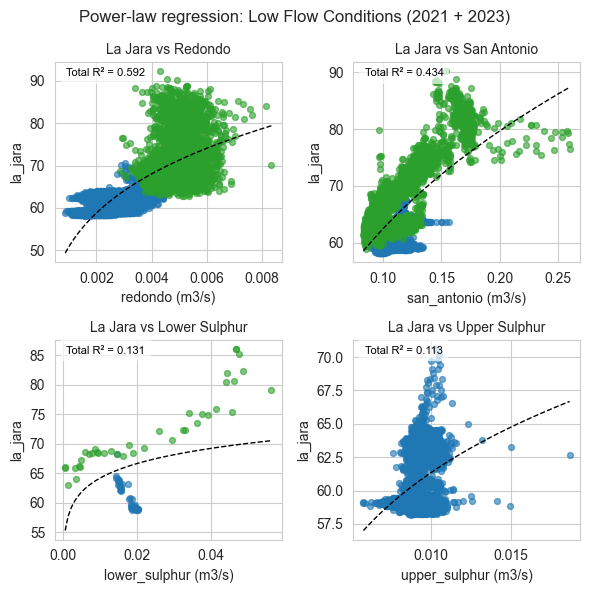

In [154]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
sns.set_style("whitegrid")
fig.suptitle("Power-law regression: Low Flow Conditions (2021 + 2023)", fontsize=12)

pairs = [
    (merged_redondo, "redondo (m3/s)", axes[0, 0], "La Jara vs Redondo"),
    (merged_san_antonio, "san_antonio (m3/s)", axes[0, 1], "La Jara vs San Antonio"),
    (merged_lower_sulphur, "lower_sulphur (m3/s)", axes[1, 0], "La Jara vs Lower Sulphur"),
    (merged_upper_sulphur, "upper_sulphur (m3/s)", axes[1, 1], "La Jara vs Upper Sulphur"),
]

colors = {"2021": "#1f77b4", "2023": "#2ca02c"}  # blue, green

for df, x_col, ax, title in pairs:
    valid_data = df[[x_col, "la_jara"]].dropna()

    # low-flow filter
    valid_data = valid_data[(valid_data.index.month >= 6) & (valid_data.index.month <= 12)]
    valid_data = valid_data[valid_data['la_jara'] >= 58] # only keep baseflow la jara

    year_subsets = []

    # scatter by year
    for year, color in colors.items():
        year_data = valid_data[valid_data.index.year == int(year)]

        # optional 2023 cutoff
        # if year == "2023":
        #     year_data = year_data[year_data.index >= "2023-06-15"]

        if len(year_data) > 0:
            ax.scatter(
                year_data[x_col],
                year_data["la_jara"],
                alpha=0.6,
                s=18,
                color=color,
                label=year
            )
            year_subsets.append(year_data)

    # combined power-law fit (2021 + 2023)
    if len(year_subsets) > 0:
        fit_data = pd.concat(year_subsets)

        # power law requires x > 0 and y > 0
        fit_data = fit_data[(fit_data[x_col] > 0) & (fit_data["la_jara"] > 0)]

        if len(fit_data) > 1:
            x = fit_data[x_col].values
            y = fit_data["la_jara"].values

            try:
                popt, _ = curve_fit(power_law, x, y, p0=[0.01, 0.1], maxfev=5000)

                y_pred = power_law(x, *popt)
                residuals = y - y_pred
                ss_res = np.sum(residuals**2)
                ss_tot = np.sum((y - np.mean(y))**2)
                r2 = 1 - (ss_res / ss_tot)

                x_line = np.linspace(x.min(), x.max(), 80)
                y_line = power_law(x_line, *popt)

                ax.plot(
                    x_line, y_line,
                    color="black", linestyle="--", linewidth=1.0,
                    label="Total fit (2021+2023)"
                )
                ax.text(
                    0.05, 0.93,
                    f"Total R² = {r2:.3f}",
                    transform=ax.transAxes,
                    fontsize=8,
                    color="black",
                    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
                )
            except Exception:
                ax.text(
                    0.05, 0.93,
                    "Power-law fit failed",
                    transform=ax.transAxes,
                    fontsize=8,
                    color="black",
                    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
                )

    ax.set_title(title, fontsize=10)
    ax.set_xlabel(x_col)
    ax.set_ylabel("la_jara")

plt.tight_layout()
plt.show()

# Final

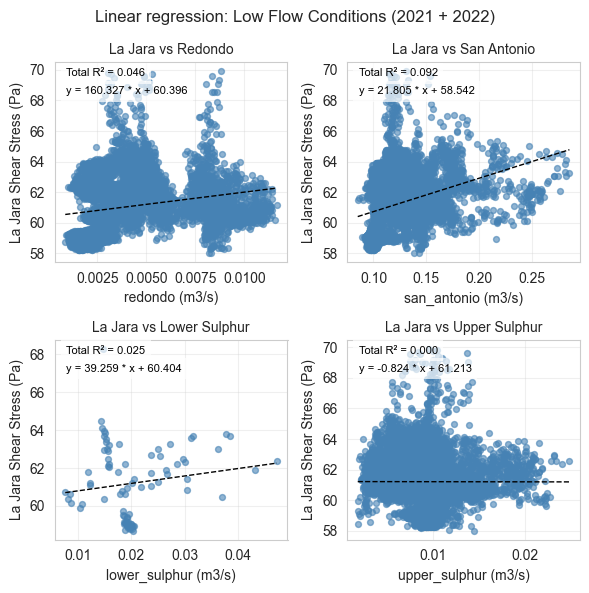

In [204]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
sns.set_style("whitegrid")
fig.suptitle("Linear regression: Low Flow Conditions (2021 + 2022)", fontsize=12)

pairs = [
    (merged_redondo, "redondo (m3/s)", axes[0, 0], "La Jara vs Redondo"),
    (merged_san_antonio, "san_antonio (m3/s)", axes[0, 1], "La Jara vs San Antonio"),
    (merged_lower_sulphur, "lower_sulphur (m3/s)", axes[1, 0], "La Jara vs Lower Sulphur"),
    (merged_upper_sulphur, "upper_sulphur (m3/s)", axes[1, 1], "La Jara vs Upper Sulphur"),
]

for df, x_col, ax, title in pairs:
    valid_data = df[[x_col, "la_jara"]].dropna()

    # keep only 2021 + 2023 (no visual separation by year)
    valid_data = valid_data[valid_data.index.year.isin([2021, 2022])]

    # low-flow filter
    valid_data = valid_data[(valid_data.index.month >= 6) & (valid_data.index.month <= 11)]
    valid_data = valid_data[valid_data["la_jara"] >= 58]  # get rid of low outliers
    valid_data = valid_data[valid_data["la_jara"] <= 70]  # get rid of high outliers


    # linear fit requires x > 0 and y > 0
    fit_data = valid_data[(valid_data[x_col] > 0) & (valid_data["la_jara"] > 0)]

    # one scatter style for all points
    ax.scatter(
        fit_data[x_col],
        fit_data["la_jara"],
        alpha=0.6,
        s=18,
        color="steelblue"
    )

    if len(fit_data) > 1:
        x = fit_data[x_col].values
        y = fit_data["la_jara"].values

        try:
            slope, intercept, r_value, p_value, std_err = linregress(x, y)
            r2 = r_value**2

            x_line = np.linspace(x.min(), x.max(), 80)
            y_line = slope * x_line + intercept
            ax.plot(x_line, y_line, color="black", linestyle="--", linewidth=1.0)

            # equation text
            eq_text = f"y = {slope:.3f} * x + {intercept:.3f}"

            ax.text(
                0.05, 0.93,
                f"Total R² = {r2:.3f}",
                transform=ax.transAxes,
                fontsize=8,
                color="black",
                bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
            )
            ax.text(
                0.05, 0.84,
                eq_text,
                transform=ax.transAxes,
                fontsize=8,
                color="black",
                bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
            )
        except Exception:
            ax.text(
                0.05, 0.93,
                "Linear fit failed",
                transform=ax.transAxes,
                fontsize=8,
                color="black",
                bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
            )

    ax.set_title(title, fontsize=10)
    ax.set_xlabel(x_col)
    ax.set_ylabel("La Jara Shear Stress (Pa)")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

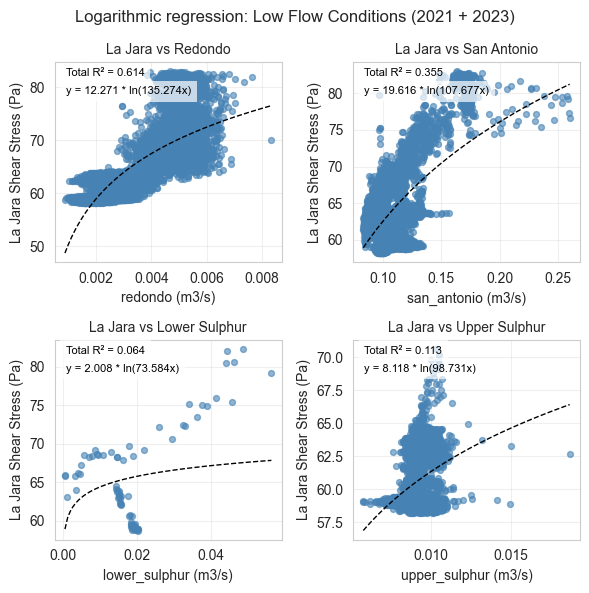

In [203]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
sns.set_style("whitegrid")
fig.suptitle("Logarithmic regression: Low Flow Conditions (2021 + 2023)", fontsize=12)

pairs = [
    (merged_redondo, "redondo (m3/s)", axes[0, 0], "La Jara vs Redondo"),
    (merged_san_antonio, "san_antonio (m3/s)", axes[0, 1], "La Jara vs San Antonio"),
    (merged_lower_sulphur, "lower_sulphur (m3/s)", axes[1, 0], "La Jara vs Lower Sulphur"),
    (merged_upper_sulphur, "upper_sulphur (m3/s)", axes[1, 1], "La Jara vs Upper Sulphur"),
]

for df, x_col, ax, title in pairs:
    valid_data = df[[x_col, "la_jara"]].dropna()

    # keep only 2021 + 2022 + 2023 (no visual separation by year)
    valid_data = valid_data[valid_data.index.year.isin([2021, 2023])]

    # low-flow filter
    valid_data = valid_data[(valid_data.index.month >= 6) & (valid_data.index.month <= 12)]
    valid_data = valid_data[valid_data['la_jara'] > 58] # only keep baseflow la jara
    valid_data = valid_data[valid_data['la_jara'] <= 83] # get rid of high outliers

    # exponential fit requires x > 0 and y > 0
    fit_data = valid_data[(valid_data[x_col] > 0) & (valid_data["la_jara"] > 0)]

    # one scatter style for all points
    ax.scatter(
        fit_data[x_col],
        fit_data["la_jara"],
        alpha=0.6,
        s=18,
        color="steelblue"
    )

    if len(fit_data) > 1:
        x = fit_data[x_col].values
        y = fit_data["la_jara"].values

        try:
            popt, _ = curve_fit(logarithmic, x, y, p0=[0.01, 0.1], maxfev=5000)

            y_pred = logarithmic(x, *popt)
            residuals = y - y_pred
            ss_res = np.sum(residuals**2)
            ss_tot = np.sum((y - np.mean(y))**2)
            r2 = 1 - (ss_res / ss_tot)

            x_line = np.linspace(x.min(), x.max(), 80)
            y_line = logarithmic(x_line, *popt)
            ax.plot(x_line, y_line, color="black", linestyle="--", linewidth=1.0)

            # equation text
            eq_text = f"y = {popt[0]:.3f} * ln({popt[1]:.3f}x)"

            ax.text(
                0.05, 0.93,
                f"Total R² = {r2:.3f}",
                transform=ax.transAxes,
                fontsize=8,
                color="black",
                bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
            )
            ax.text(
                0.05, 0.84,
                eq_text,
                transform=ax.transAxes,
                fontsize=8,
                color="black",
                bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
            )
        except Exception:
            ax.text(
                0.05, 0.93,
                "Exponential fit failed",
                transform=ax.transAxes,
                fontsize=8,
                color="black",
                bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
            )

    ax.set_title(title, fontsize=10)
    ax.set_xlabel(x_col)
    ax.set_ylabel("La Jara Shear Stress (Pa)")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show() 

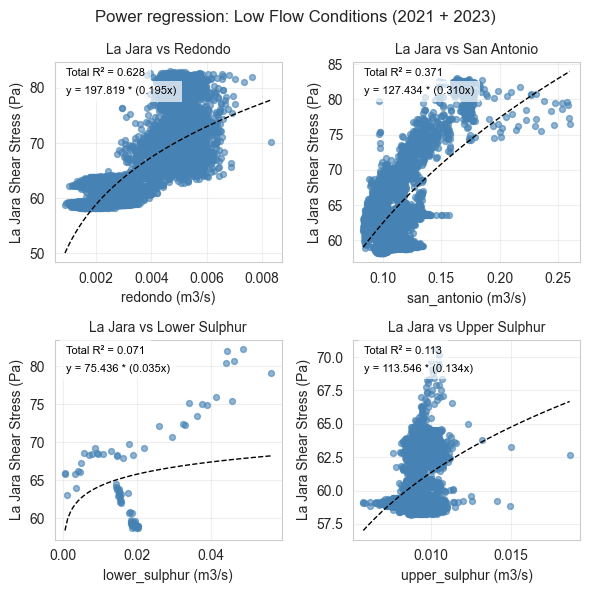

In [202]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
sns.set_style("whitegrid")
fig.suptitle("Power regression: Low Flow Conditions (2021 + 2023)", fontsize=12)

pairs = [
    (merged_redondo, "redondo (m3/s)", axes[0, 0], "La Jara vs Redondo"),
    (merged_san_antonio, "san_antonio (m3/s)", axes[0, 1], "La Jara vs San Antonio"),
    (merged_lower_sulphur, "lower_sulphur (m3/s)", axes[1, 0], "La Jara vs Lower Sulphur"),
    (merged_upper_sulphur, "upper_sulphur (m3/s)", axes[1, 1], "La Jara vs Upper Sulphur"),
]

for df, x_col, ax, title in pairs:
    valid_data = df[[x_col, "la_jara"]].dropna()

    # keep only 2021 + 2022 + 2023 (no visual separation by year)
    valid_data = valid_data[valid_data.index.year.isin([2021, 2023])]

    # low-flow filter
    valid_data = valid_data[(valid_data.index.month >= 6) & (valid_data.index.month <= 12)]
    valid_data = valid_data[valid_data['la_jara'] > 58] # only keep baseflow la jara
    valid_data = valid_data[valid_data['la_jara'] <= 83] # get rid of high outliers

    # exponential fit requires x > 0 and y > 0
    fit_data = valid_data[(valid_data[x_col] > 0) & (valid_data["la_jara"] > 0)]

    # one scatter style for all points
    ax.scatter(
        fit_data[x_col],
        fit_data["la_jara"],
        alpha=0.6,
        s=18,
        color="steelblue"
    )

    if len(fit_data) > 1:
        x = fit_data[x_col].values
        y = fit_data["la_jara"].values

        try:
            popt, _ = curve_fit(power_law, x, y, p0=[1.0, 1.0], maxfev=5000)

            y_pred = power_law(x, *popt)
            residuals = y - y_pred
            ss_res = np.sum(residuals**2)
            ss_tot = np.sum((y - np.mean(y))**2)
            r2 = 1 - (ss_res / ss_tot)

            x_line = np.linspace(x.min(), x.max(), 80)
            y_line = power_law(x_line, *popt)
            ax.plot(x_line, y_line, color="black", linestyle="--", linewidth=1.0)

            # equation text
            eq_text = f"y = {popt[0]:.3f} * ({popt[1]:.3f}x)"

            ax.text(
                0.05, 0.93,
                f"Total R² = {r2:.3f}",
                transform=ax.transAxes,
                fontsize=8,
                color="black",
                bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
            )
            ax.text(
                0.05, 0.84,
                eq_text,
                transform=ax.transAxes,
                fontsize=8,
                color="black",
                bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
            )
        except Exception:
            ax.text(
                0.05, 0.93,
                "Power law fit failed",
                transform=ax.transAxes,
                fontsize=8,
                color="black",
                bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
            )

    ax.set_title(title, fontsize=10)
    ax.set_xlabel(x_col)
    ax.set_ylabel("La Jara Shear Stress (Pa)")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show() 